In [29]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import time
import pandas as pd
from numpy.testing import verbose
from stable_baselines3 import PPO
from sb3_contrib import TRPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.results_plotter import load_results, ts2xy

In [3]:
### Properties of the environment

env_id = "CartPole-v1"
env_steps = 1_000_000
env_eval = 50
seed = 42
np.random.seed(seed)

In [26]:
### Training and Evaluation Loop

def train_and_eval(algo, env_id, env_steps, log_dir, seed = 42, n_eval = 50):
    t0 = time.time()
    train_env = make_vec_env(env_id, n_envs=6, seed =seed, monitor_dir=log_dir)
    eval_env = make_vec_env(env_id,  n_envs=1, seed = int(seed*45.5))
    model = algo('MlpPolicy', train_env, verbose = 0, seed =seed)
    model.learn(total_timesteps = env_steps)
    mean_r, str_r = evaluate_policy(model , eval_env, n_eval_episodes = n_eval, deterministic=True)
    train_env.close()
    eval_env.close()
    return model, mean_r, str_r, t0

In [27]:
### Training the model and saving the trained model

ppo_model, ppo_mean, ppo_str_r, ppo_t0 = train_and_eval(PPO, env_id, env_steps, log_dir="./logs/PPO", seed=42, n_eval=50)
tf = time.time()
ppo_model.save('ppo_cartpole_model')
print(f'PPO Reward = {ppo_mean} +- {ppo_str_r} && time = {tf-ppo_t0} secs')

PPO Reward = 500.0 +- 0.0 && time = 317.11277651786804 secs


In [13]:
### Reusing the saved model

ppo_loaded = PPO.load('ppo_cartpole_model')
t0 = time.time()
env_eval = make_vec_env(env_id, n_envs=1)
mean_reward, std_dev = evaluate_policy(ppo_loaded, env_eval, n_eval_episodes=50, deterministic=True)
tf = time.time()
print(f'Reward is {mean_reward} +- {std_dev} in {tf-t0} secs approx')

Reward is 500.0 +- 0.0 in 4.105923891067505 secs approx


In [28]:
trpo_model , trpo_mean, trpo_str, trpo_t0 = train_and_eval(TRPO, env_id, env_steps, log_dir="./logs/TRPO", seed = 42, n_eval=50)
tf = time.time()
trpo_model.save('TRPO saved model')
print(f'The TRPO reward is {trpo_mean} +- {trpo_str} and it took {tf-trpo_t0} secs')

The TRPO reward is 500.0 +- 0.0 and it took 183.38626837730408 secs


In [15]:
trpo_loaded = TRPO.load('TRPO saved model')
t0 = time.time()
env_eval = make_vec_env(env_id, n_envs=1)
trpo_reward, trpo_str_r = evaluate_policy(trpo_loaded, env_eval, n_eval_episodes=50, deterministic=True)
tf = time.time()
print(f'TRPO reward = {trpo_reward} +- {trpo_str_r} && time taken during loading = {tf-t0} secs')

TRPO reward = 500.0 +- 0.0 && time taken during loading = 4.09587550163269 secs


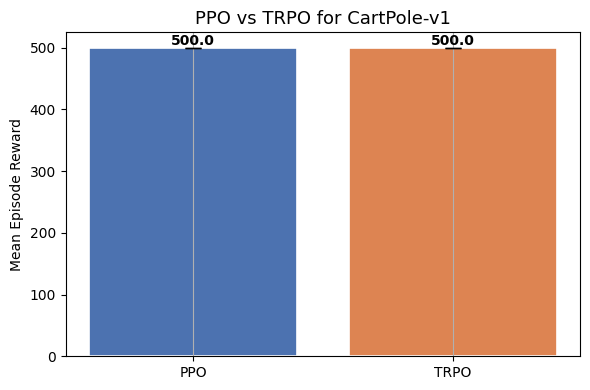

In [25]:
### Plots

algos = ['PPO', 'TRPO']
means = [ppo_mean, trpo_mean]
stds = [ppo_str_r, trpo_str]
colors = ['#4C72B0', '#DD8452']
fig, ax = plt.subplots(figsize=(6,4))

bars = ax.bar(algos, means, yerr=stds, capsize = 6, color = colors, edgecolor='white', linewidth=1.2)
for bar, m in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width() /2, bar.get_height() + max(stds) * 0.1, f"{m:.1f}",ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title(f'PPO vs TRPO for {env_id}', fontsize =13)
ax.set_ylabel('Mean Episode Reward')
ax.grid(axis='y', linestyle="-", alpha = 1)
plt.tight_layout()
plt.grid()
plt.show()

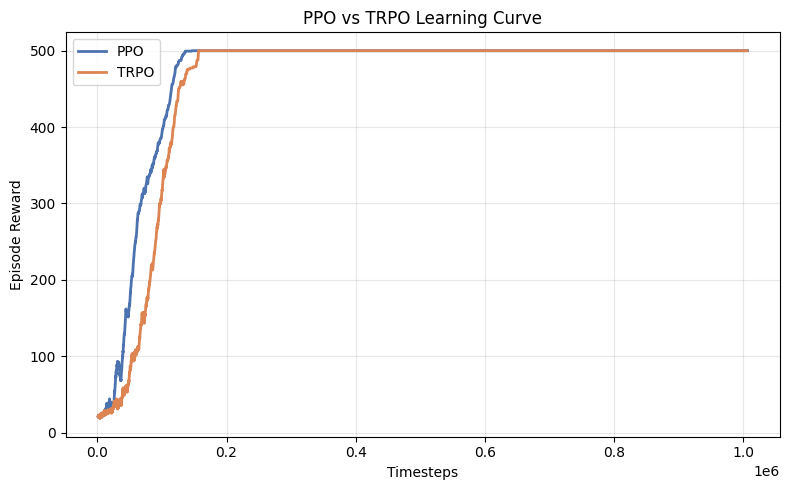

In [30]:
### Ploting the learning curves!

def plot_learning_curve(log_dir, label, color):
    x, y = ts2xy(load_results(log_dir), 'timesteps')
    y_smooth = pd.Series(y).rolling(window=50).mean()
    plt.plot(x, y_smooth, label = label, color=color, linewidth =2)
plt.figure(figsize=(8,5))
plot_learning_curve('./logs/PPO', 'PPO', '#4C72B0')
plot_learning_curve('./logs/TRPO', 'TRPO', '#DD8452')

plt.title("PPO vs TRPO Learning Curve")
plt.xlabel('Timesteps')
plt.ylabel('Episode Reward')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()